# Dose Profile Comparisons Summary

This notebook provides a comprehensive summary of comparisons between:
1. **CCB vs AIC144** - comparing two facilities
2. **MC vs EBT3** - comparing Monte Carlo simulations with EBT3 dosimetry measurements

## Data Sources
- **MC (Monte Carlo)**: Simulation data for depth-dose profiles
- **EBT3**: Radiochromic film dosimetry measurements
- **CCB**: Cyclotron Centre Bronowice
- **AIC144**: Alternative irradiation configuration

In [16]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

In [17]:
# File paths for all data
BASE_PATH = Path(r"C:\Users\grzanka\workspace\osl_mb_foils\notebooks\pub_something_2026")

# MC files
MC_CCB_FILE = BASE_PATH / "mc" / "mc_ccb_big.csv"
MC_AIC144_FILE = BASE_PATH / "mc" / "mc_aic144_big.csv"

# EBT files
EBT_CCB_FILE = BASE_PATH / "ebt_foils" / "ebt_profile_ccb.csv"
EBT_AIC144_FILE = BASE_PATH / "ebt_foils" / "ebt_profile_aic144.csv"

# MBO files
MBO_CCB_FILE = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_ccb\2025-12-19\profile_foils_3_2.npz")
MBO_AIC144_FILE = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_aic144\2025-11-25\mbo_aic144_single_foil_rotated.npz")

# Verify files exist
print("File verification:")
print(f"  MC CCB:     {MC_CCB_FILE.exists()}")
print(f"  MC AIC144:  {MC_AIC144_FILE.exists()}")
print(f"  EBT CCB:    {EBT_CCB_FILE.exists()}")
print(f"  EBT AIC144: {EBT_AIC144_FILE.exists()}")
print(f"  MBO CCB:    {MBO_CCB_FILE.exists()}")
print(f"  MBO AIC144: {MBO_AIC144_FILE.exists()}")

File verification:
  MC CCB:     True
  MC AIC144:  True
  EBT CCB:    True
  EBT AIC144: True
  MBO CCB:    True
  MBO AIC144: True


In [18]:
# Load all data
# MC data: columns - depth (mm), dose (normalized), fluence, kinetic_energy
# EBT data: columns - x_mm (mm), dose_Gy (Gy)

df_mc_ccb = pd.read_csv(MC_CCB_FILE)
df_mc_aic144 = pd.read_csv(MC_AIC144_FILE)
df_ebt_ccb = pd.read_csv(EBT_CCB_FILE)
df_ebt_aic144 = pd.read_csv(EBT_AIC144_FILE)

# Load MBO data
mbo_ccb_data = np.load(MBO_CCB_FILE)
mbo_ccb_x = mbo_ccb_data['x_mm']
mbo_ccb_values = mbo_ccb_data['profile_opt_smooth']

mbo_aic144_data = np.load(MBO_AIC144_FILE)
mbo_aic144_x = mbo_aic144_data['profile_x_mm']
mbo_aic144_values = mbo_aic144_data['profile_values']

print("Data loaded successfully:")
print(f"  MC CCB:     {df_mc_ccb.shape}")
print(f"  MC AIC144:  {df_mc_aic144.shape}")
print(f"  EBT CCB:    {df_ebt_ccb.shape}")
print(f"  EBT AIC144: {df_ebt_aic144.shape}")
print(f"  MBO CCB:    x={mbo_ccb_x.shape}, values={mbo_ccb_values.shape}")
print(f"  MBO AIC144: x={mbo_aic144_x.shape}, values={mbo_aic144_values.shape}")

Data loaded successfully:
  MC CCB:     (640, 7)
  MC AIC144:  (640, 7)
  EBT CCB:    (264, 2)
  EBT AIC144: (304, 2)
  MBO CCB:    x=(555,), values=(555,)
  MBO AIC144: x=(1024,), values=(1024,)


In [19]:
def calculate_fwhm(x, y):
    """Calculate Full Width at Half Maximum."""
    y_max = np.max(y)
    half_max = y_max / 2
    
    above_half = y >= half_max
    transitions = np.diff(above_half.astype(int))
    rising_idx = np.where(transitions == 1)[0]
    falling_idx = np.where(transitions == -1)[0]
    
    if len(rising_idx) > 0 and len(falling_idx) > 0:
        x_left = x[rising_idx[0]]
        x_right = x[falling_idx[-1]]
        return x_right - x_left, x_left, x_right, half_max
    return None, None, None, None

def find_distal_percent(x, y, percent):
    """Find position where dose drops to given percent on the distal side."""
    y_max = np.max(y)
    dose_threshold = percent * y_max
    
    idx_max = np.argmax(y)
    x_max = x[idx_max]
    
    # Look only at distal part
    distal_mask = x > x_max
    x_distal = x[distal_mask]
    y_distal = y[distal_mask]
    
    below_threshold = y_distal < dose_threshold
    if np.any(below_threshold):
        idx = np.where(below_threshold)[0][0]
        return x_distal[idx]
    return None

def find_90_percent_distal(x, y):
    """Find position where dose drops to 90% on the distal side."""
    x90 = find_distal_percent(x, y, 0.9)
    return x90, None

def calculate_distal_falloff_80_20(x, y):
    """Calculate distal falloff distance from 80% to 20%."""
    x80 = find_distal_percent(x, y, 0.8)
    x20 = find_distal_percent(x, y, 0.2)
    if x80 is not None and x20 is not None:
        return x20 - x80
    return None

def normalize_to_x0(x, y, x_ref=0):
    """Create interpolator and normalize data to reference position."""
    interp_func = interp1d(x, y, kind='linear', fill_value='extrapolate')
    dose_at_ref = float(interp_func(x_ref))
    return interp_func, dose_at_ref

def get_dense_data(x, y, n_points=1000):
    """Create interpolated dense data for accurate metrics calculation."""
    interp = interp1d(x, y, kind='linear', fill_value='extrapolate')
    x_dense = np.linspace(x.min(), x.max(), n_points)
    y_dense = interp(x_dense)
    return x_dense, y_dense

def calculate_all_metrics(x, y):
    """Calculate all metrics: FWHM, X90%, distal falloff 80-20."""
    x_dense, y_dense = get_dense_data(x, y)
    fwhm, _, _, _ = calculate_fwhm(x_dense, y_dense)
    x90 = find_distal_percent(x_dense, y_dense, 0.9)
    falloff_80_20 = calculate_distal_falloff_80_20(x_dense, y_dense)
    return fwhm, x90, falloff_80_20

def add_metrics_box(ax, metrics_dict, position='upper left', fontsize=9):
    """Add a text box with metrics to the plot."""
    text_lines = []
    for label, (value, color) in metrics_dict.items():
        if value is not None:
            text_lines.append(f"{label}: {value:.2f} mm")
        else:
            text_lines.append(f"{label}: N/A")
    
    text = '\n'.join(text_lines)
    
    # Position mapping
    pos_map = {
        'upper left': (0.02, 0.98),
        'upper right': (0.98, 0.98),
        'lower left': (0.02, 0.02),
        'lower right': (0.98, 0.02)
    }
    ha_map = {'upper left': 'left', 'upper right': 'right', 'lower left': 'left', 'lower right': 'right'}
    va_map = {'upper left': 'top', 'upper right': 'top', 'lower left': 'bottom', 'lower right': 'bottom'}
    
    x_pos, y_pos = pos_map.get(position, (0.02, 0.98))
    ha = ha_map.get(position, 'left')
    va = va_map.get(position, 'top')
    
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(x_pos, y_pos, text, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment=va, horizontalalignment=ha, bbox=props, family='monospace')

In [20]:
# Prepare MBO data - shift to align max with EBT max and scale to match EBT at X=0

# CCB MBO alignment
ebt_interp_ccb, ebt_dose_at_0_ccb = normalize_to_x0(df_ebt_ccb['x_mm'], df_ebt_ccb['dose_Gy'])
ebt_max_idx_ccb = df_ebt_ccb['dose_Gy'].idxmax()
ebt_max_x_ccb = df_ebt_ccb.loc[ebt_max_idx_ccb, 'x_mm']

mbo_max_idx_ccb = np.argmax(mbo_ccb_values)
mbo_max_x_ccb = mbo_ccb_x[mbo_max_idx_ccb]
mbo_ccb_x_shift = ebt_max_x_ccb - mbo_max_x_ccb
mbo_ccb_x_shifted = mbo_ccb_x + mbo_ccb_x_shift

mbo_interp_ccb = interp1d(mbo_ccb_x_shifted, mbo_ccb_values, kind='linear', fill_value='extrapolate')
mbo_value_at_0_ccb = float(mbo_interp_ccb(0))
scale_mbo_ccb = ebt_dose_at_0_ccb / mbo_value_at_0_ccb
mbo_ccb_values_scaled = mbo_ccb_values * scale_mbo_ccb

# AIC144 MBO alignment
ebt_interp_aic144, ebt_dose_at_0_aic144 = normalize_to_x0(df_ebt_aic144['x_mm'], df_ebt_aic144['dose_Gy'])
ebt_max_idx_aic144 = df_ebt_aic144['dose_Gy'].idxmax()
ebt_max_x_aic144 = df_ebt_aic144.loc[ebt_max_idx_aic144, 'x_mm']

mbo_max_idx_aic144 = np.argmax(mbo_aic144_values)
mbo_max_x_aic144 = mbo_aic144_x[mbo_max_idx_aic144]
mbo_aic144_x_shift = ebt_max_x_aic144 - mbo_max_x_aic144
mbo_aic144_x_shifted = mbo_aic144_x + mbo_aic144_x_shift

mbo_interp_aic144 = interp1d(mbo_aic144_x_shifted, mbo_aic144_values, kind='linear', fill_value='extrapolate')
mbo_value_at_0_aic144 = float(mbo_interp_aic144(0))
scale_mbo_aic144 = ebt_dose_at_0_aic144 / mbo_value_at_0_aic144
mbo_aic144_values_scaled = mbo_aic144_values * scale_mbo_aic144

print("MBO data prepared:")
print(f"  CCB: shift={mbo_ccb_x_shift:.2f} mm, scale={scale_mbo_ccb:.6f}")
print(f"  AIC144: shift={mbo_aic144_x_shift:.2f} mm, scale={scale_mbo_aic144:.6f}")

MBO data prepared:
  CCB: shift=-8.28 mm, scale=0.006042
  AIC144: shift=-25.62 mm, scale=0.007846


## 1. CCB vs AIC144 Comparison

Comparing dose profiles between the two facilities using EBT3 measurements and MC simulations.

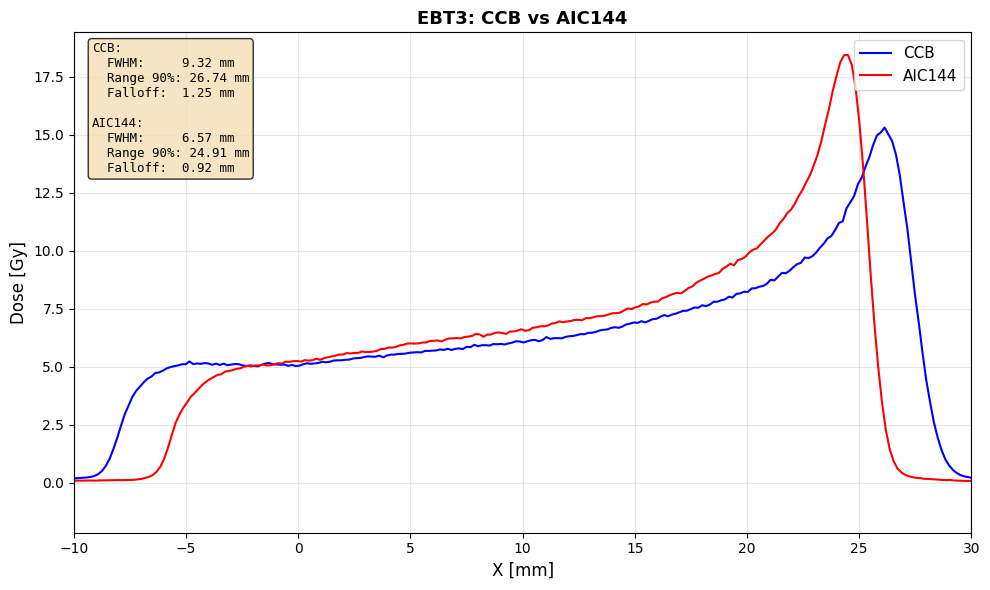

In [21]:
# CCB vs AIC144: EBT3 Comparison
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate metrics for EBT3 data
fwhm_ccb, x90_ccb, falloff_ccb = calculate_all_metrics(df_ebt_ccb['x_mm'].values, df_ebt_ccb['dose_Gy'].values)
fwhm_aic, x90_aic, falloff_aic = calculate_all_metrics(df_ebt_aic144['x_mm'].values, df_ebt_aic144['dose_Gy'].values)

# Plot absolute dose
ax.plot(df_ebt_ccb['x_mm'], df_ebt_ccb['dose_Gy'], 'b-', linewidth=1.5, label='CCB')
ax.plot(df_ebt_aic144['x_mm'], df_ebt_aic144['dose_Gy'], 'r-', linewidth=1.5, label='AIC144')
ax.set_xlabel('X [mm]', fontsize=12)
ax.set_ylabel('Dose [Gy]', fontsize=12)
ax.set_title('EBT3: CCB vs AIC144', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(-10, 30)

# Add metrics box
metrics_text = (
    f"CCB:\n"
    f"  FWHM:     {fwhm_ccb:.2f} mm\n"
    f"  Range 90%: {x90_ccb:.2f} mm\n"
    f"  Falloff:  {falloff_ccb:.2f} mm\n"
    f"\n"
    f"AIC144:\n"
    f"  FWHM:     {fwhm_aic:.2f} mm\n"
    f"  Range 90%: {x90_aic:.2f} mm\n"
    f"  Falloff:  {falloff_aic:.2f} mm"
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='left', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

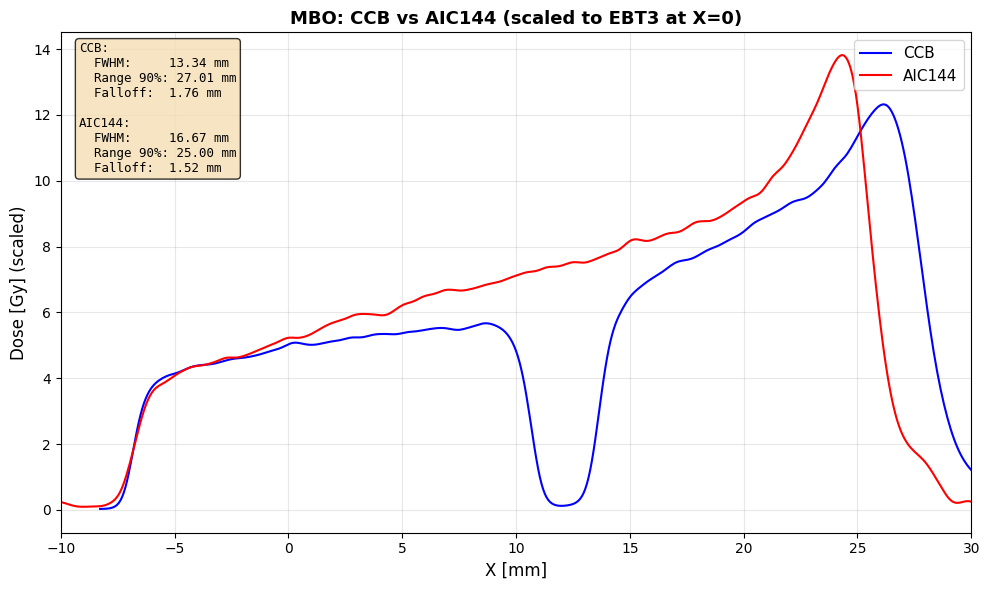

In [22]:
# CCB vs AIC144: MBO Comparison
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate metrics for MBO data
fwhm_mbo_ccb, x90_mbo_ccb, falloff_mbo_ccb = calculate_all_metrics(mbo_ccb_x_shifted, mbo_ccb_values_scaled)
fwhm_mbo_aic, x90_mbo_aic, falloff_mbo_aic = calculate_all_metrics(mbo_aic144_x_shifted, mbo_aic144_values_scaled)

# Plot MBO dose (scaled)
ax.plot(mbo_ccb_x_shifted, mbo_ccb_values_scaled, 'b-', linewidth=1.5, label='CCB')
ax.plot(mbo_aic144_x_shifted, mbo_aic144_values_scaled, 'r-', linewidth=1.5, label='AIC144')
ax.set_xlabel('X [mm]', fontsize=12)
ax.set_ylabel('Dose [Gy] (scaled)', fontsize=12)
ax.set_title('MBO: CCB vs AIC144 (scaled to EBT3 at X=0)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(-10, 30)

# Add metrics box
metrics_text = (
    f"CCB:\n"
    f"  FWHM:     {fwhm_mbo_ccb:.2f} mm\n"
    f"  Range 90%: {x90_mbo_ccb:.2f} mm\n"
    f"  Falloff:  {falloff_mbo_ccb:.2f} mm\n"
    f"\n"
    f"AIC144:\n"
    f"  FWHM:     {fwhm_mbo_aic:.2f} mm\n"
    f"  Range 90%: {x90_mbo_aic:.2f} mm\n"
    f"  Falloff:  {falloff_mbo_aic:.2f} mm"
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='left', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

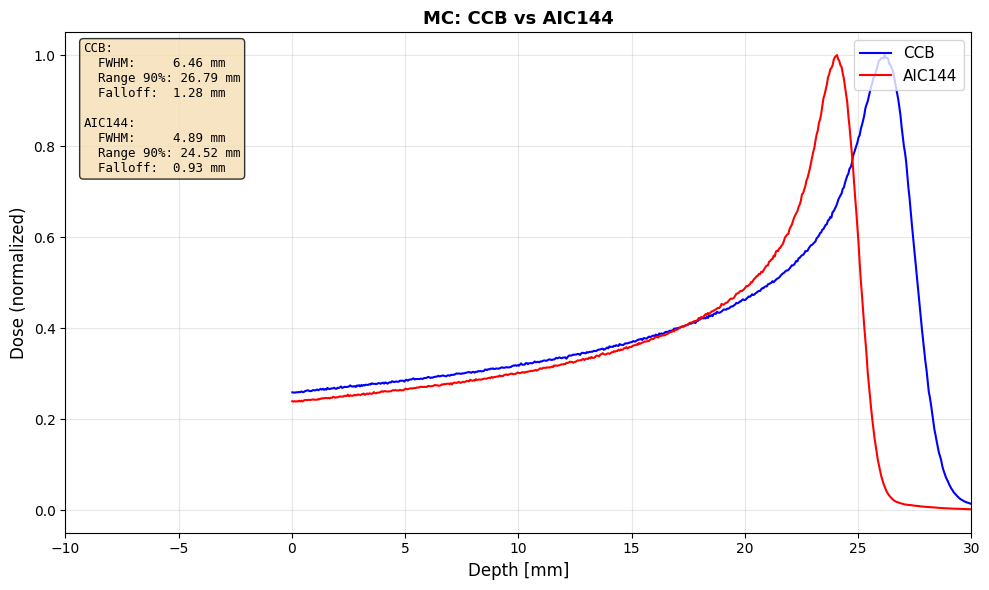

In [23]:
# CCB vs AIC144: MC Comparison
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate metrics for MC data
fwhm_ccb_mc, x90_ccb_mc, falloff_ccb_mc = calculate_all_metrics(df_mc_ccb['depth'].values, df_mc_ccb['dose'].values)
fwhm_aic_mc, x90_aic_mc, falloff_aic_mc = calculate_all_metrics(df_mc_aic144['depth'].values, df_mc_aic144['dose'].values)

# Plot MC dose
ax.plot(df_mc_ccb['depth'], df_mc_ccb['dose'], 'b-', linewidth=1.5, label='CCB')
ax.plot(df_mc_aic144['depth'], df_mc_aic144['dose'], 'r-', linewidth=1.5, label='AIC144')
ax.set_xlabel('Depth [mm]', fontsize=12)
ax.set_ylabel('Dose (normalized)', fontsize=12)
ax.set_title('MC: CCB vs AIC144', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(-10, 30)

# Add metrics box
metrics_text = (
    f"CCB:\n"
    f"  FWHM:     {fwhm_ccb_mc:.2f} mm\n"
    f"  Range 90%: {x90_ccb_mc:.2f} mm\n"
    f"  Falloff:  {falloff_ccb_mc:.2f} mm\n"
    f"\n"
    f"AIC144:\n"
    f"  FWHM:     {fwhm_aic_mc:.2f} mm\n"
    f"  Range 90%: {x90_aic_mc:.2f} mm\n"
    f"  Falloff:  {falloff_aic_mc:.2f} mm"
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, metrics_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='left', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

## 2. MC vs EBT3 Comparison

Comparing Monte Carlo simulation results with EBT3 film dosimetry measurements for each facility.

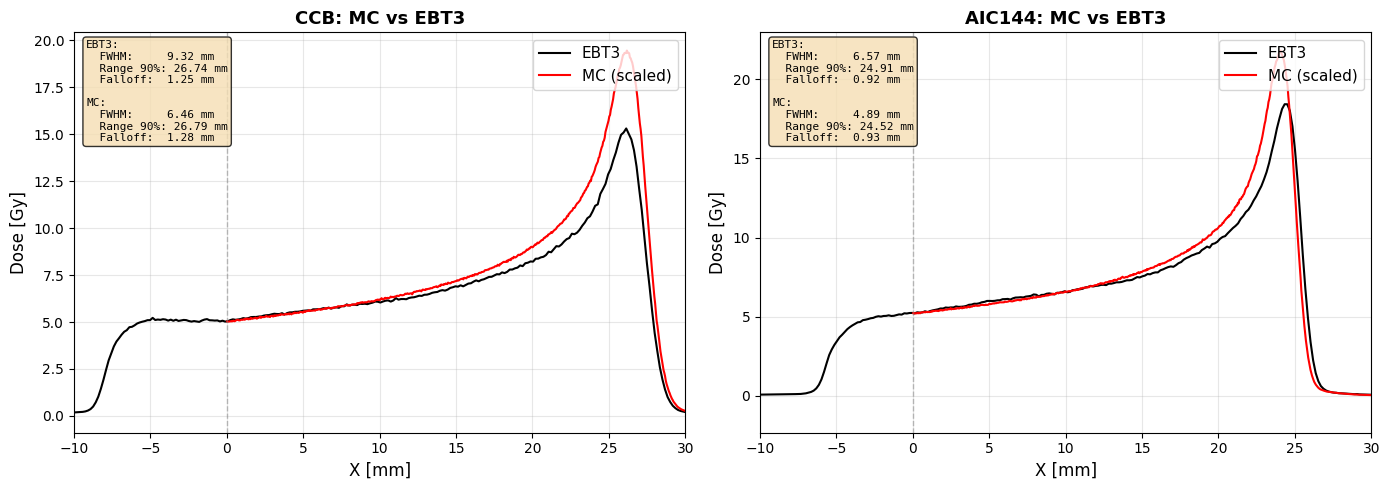

CCB scale factor (EBT/MC at X=0): 19.4495
AIC144 scale factor (EBT/MC at X=0): 21.8161


In [24]:
# MC vs EBT3 for both facilities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scale MC to match EBT at X=0 for each facility
# CCB
ebt_interp_ccb, ebt_dose_at_0_ccb = normalize_to_x0(df_ebt_ccb['x_mm'], df_ebt_ccb['dose_Gy'])
mc_interp_ccb, mc_dose_at_0_ccb = normalize_to_x0(df_mc_ccb['depth'], df_mc_ccb['dose'])
scale_ccb = ebt_dose_at_0_ccb / mc_dose_at_0_ccb
df_mc_ccb['dose_scaled'] = df_mc_ccb['dose'] * scale_ccb

# AIC144
ebt_interp_aic144, ebt_dose_at_0_aic144 = normalize_to_x0(df_ebt_aic144['x_mm'], df_ebt_aic144['dose_Gy'])
mc_interp_aic144, mc_dose_at_0_aic144 = normalize_to_x0(df_mc_aic144['depth'], df_mc_aic144['dose'])
scale_aic144 = ebt_dose_at_0_aic144 / mc_dose_at_0_aic144
df_mc_aic144['dose_scaled'] = df_mc_aic144['dose'] * scale_aic144

# Calculate metrics for CCB
fwhm_ebt_ccb, x90_ebt_ccb, falloff_ebt_ccb = calculate_all_metrics(df_ebt_ccb['x_mm'].values, df_ebt_ccb['dose_Gy'].values)
fwhm_mc_ccb, x90_mc_ccb, falloff_mc_ccb = calculate_all_metrics(df_mc_ccb['depth'].values, df_mc_ccb['dose_scaled'].values)

# Calculate metrics for AIC144
fwhm_ebt_aic, x90_ebt_aic, falloff_ebt_aic = calculate_all_metrics(df_ebt_aic144['x_mm'].values, df_ebt_aic144['dose_Gy'].values)
fwhm_mc_aic, x90_mc_aic, falloff_mc_aic = calculate_all_metrics(df_mc_aic144['depth'].values, df_mc_aic144['dose_scaled'].values)

# Left plot: CCB
ax1 = axes[0]
ax1.plot(df_ebt_ccb['x_mm'], df_ebt_ccb['dose_Gy'], 'k-', linewidth=1.5, label='EBT3')
ax1.plot(df_mc_ccb['depth'], df_mc_ccb['dose_scaled'], 'r-', linewidth=1.5, label='MC (scaled)')
ax1.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('X [mm]', fontsize=12)
ax1.set_ylabel('Dose [Gy]', fontsize=12)
ax1.set_title('CCB: MC vs EBT3', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-10, 30)

# Add metrics box for CCB
metrics_text_ccb = (
    f"EBT3:\n"
    f"  FWHM:     {fwhm_ebt_ccb:.2f} mm\n"
    f"  Range 90%: {x90_ebt_ccb:.2f} mm\n"
    f"  Falloff:  {falloff_ebt_ccb:.2f} mm\n"
    f"\n"
    f"MC:\n"
    f"  FWHM:     {fwhm_mc_ccb:.2f} mm\n"
    f"  Range 90%: {x90_mc_ccb:.2f} mm\n"
    f"  Falloff:  {falloff_mc_ccb:.2f} mm"
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.02, 0.98, metrics_text_ccb, transform=ax1.transAxes, fontsize=8,
        verticalalignment='top', horizontalalignment='left', bbox=props, family='monospace')

# Right plot: AIC144
ax2 = axes[1]
ax2.plot(df_ebt_aic144['x_mm'], df_ebt_aic144['dose_Gy'], 'k-', linewidth=1.5, label='EBT3')
ax2.plot(df_mc_aic144['depth'], df_mc_aic144['dose_scaled'], 'r-', linewidth=1.5, label='MC (scaled)')
ax2.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('X [mm]', fontsize=12)
ax2.set_ylabel('Dose [Gy]', fontsize=12)
ax2.set_title('AIC144: MC vs EBT3', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-10, 30)

# Add metrics box for AIC144
metrics_text_aic = (
    f"EBT3:\n"
    f"  FWHM:     {fwhm_ebt_aic:.2f} mm\n"
    f"  Range 90%: {x90_ebt_aic:.2f} mm\n"
    f"  Falloff:  {falloff_ebt_aic:.2f} mm\n"
    f"\n"
    f"MC:\n"
    f"  FWHM:     {fwhm_mc_aic:.2f} mm\n"
    f"  Range 90%: {x90_mc_aic:.2f} mm\n"
    f"  Falloff:  {falloff_mc_aic:.2f} mm"
)
ax2.text(0.02, 0.98, metrics_text_aic, transform=ax2.transAxes, fontsize=8,
        verticalalignment='top', horizontalalignment='left', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

print(f"CCB scale factor (EBT/MC at X=0): {scale_ccb:.4f}")
print(f"AIC144 scale factor (EBT/MC at X=0): {scale_aic144:.4f}")

## 2a. EBT3 vs MBO Comparison

Comparing EBT3 film dosimetry measurements with MBO foil measurements for each facility.

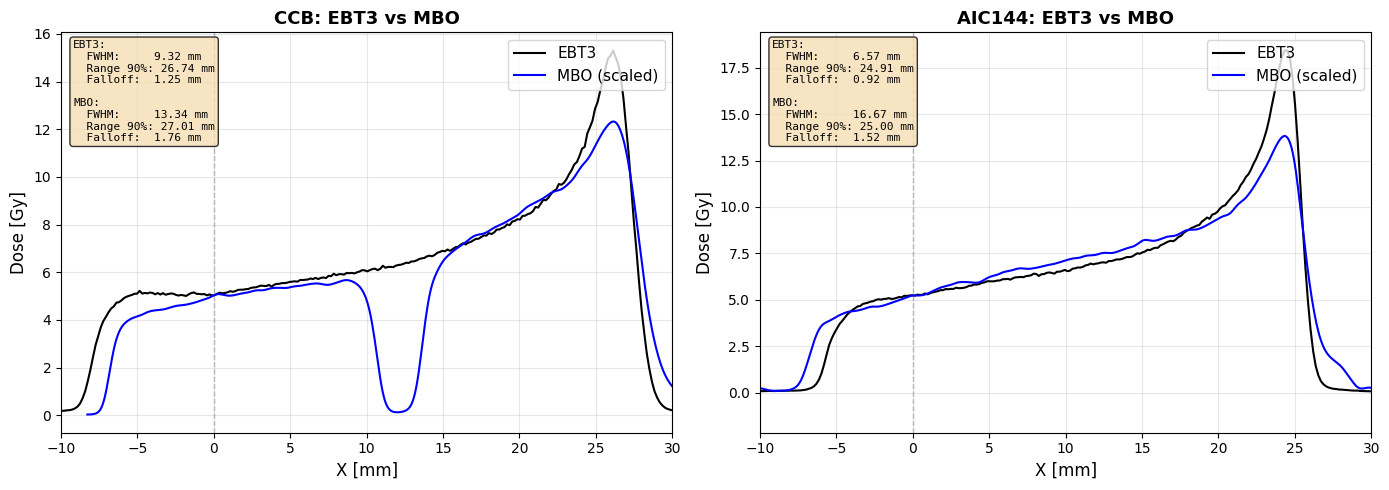

In [25]:
# EBT3 vs MBO for both facilities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: CCB
ax1 = axes[0]
ax1.plot(df_ebt_ccb['x_mm'], df_ebt_ccb['dose_Gy'], 'k-', linewidth=1.5, label='EBT3')
ax1.plot(mbo_ccb_x_shifted, mbo_ccb_values_scaled, 'b-', linewidth=1.5, label='MBO (scaled)')
ax1.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('X [mm]', fontsize=12)
ax1.set_ylabel('Dose [Gy]', fontsize=12)
ax1.set_title('CCB: EBT3 vs MBO', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-10, 30)

# Metrics for CCB
fwhm_ebt_ccb, x90_ebt_ccb, falloff_ebt_ccb = calculate_all_metrics(df_ebt_ccb['x_mm'].values, df_ebt_ccb['dose_Gy'].values)
fwhm_mbo_ccb, x90_mbo_ccb, falloff_mbo_ccb = calculate_all_metrics(mbo_ccb_x_shifted, mbo_ccb_values_scaled)

metrics_text_ccb = (
    f"EBT3:\n"
    f"  FWHM:     {fwhm_ebt_ccb:.2f} mm\n"
    f"  Range 90%: {x90_ebt_ccb:.2f} mm\n"
    f"  Falloff:  {falloff_ebt_ccb:.2f} mm\n"
    f"\n"
    f"MBO:\n"
    f"  FWHM:     {fwhm_mbo_ccb:.2f} mm\n"
    f"  Range 90%: {x90_mbo_ccb:.2f} mm\n"
    f"  Falloff:  {falloff_mbo_ccb:.2f} mm"
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.02, 0.98, metrics_text_ccb, transform=ax1.transAxes, fontsize=8,
        verticalalignment='top', horizontalalignment='left', bbox=props, family='monospace')

# Right plot: AIC144
ax2 = axes[1]
ax2.plot(df_ebt_aic144['x_mm'], df_ebt_aic144['dose_Gy'], 'k-', linewidth=1.5, label='EBT3')
ax2.plot(mbo_aic144_x_shifted, mbo_aic144_values_scaled, 'b-', linewidth=1.5, label='MBO (scaled)')
ax2.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('X [mm]', fontsize=12)
ax2.set_ylabel('Dose [Gy]', fontsize=12)
ax2.set_title('AIC144: EBT3 vs MBO', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-10, 30)

# Metrics for AIC144
fwhm_ebt_aic, x90_ebt_aic, falloff_ebt_aic = calculate_all_metrics(df_ebt_aic144['x_mm'].values, df_ebt_aic144['dose_Gy'].values)
fwhm_mbo_aic, x90_mbo_aic, falloff_mbo_aic = calculate_all_metrics(mbo_aic144_x_shifted, mbo_aic144_values_scaled)

metrics_text_aic = (
    f"EBT3:\n"
    f"  FWHM:     {fwhm_ebt_aic:.2f} mm\n"
    f"  Range 90%: {x90_ebt_aic:.2f} mm\n"
    f"  Falloff:  {falloff_ebt_aic:.2f} mm\n"
    f"\n"
    f"MBO:\n"
    f"  FWHM:     {fwhm_mbo_aic:.2f} mm\n"
    f"  Range 90%: {x90_mbo_aic:.2f} mm\n"
    f"  Falloff:  {falloff_mbo_aic:.2f} mm"
)
ax2.text(0.02, 0.98, metrics_text_aic, transform=ax2.transAxes, fontsize=8,
        verticalalignment='top', horizontalalignment='left', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

## 2b. MC vs MBO Comparison

Comparing Monte Carlo simulation results with MBO foil measurements for each facility.

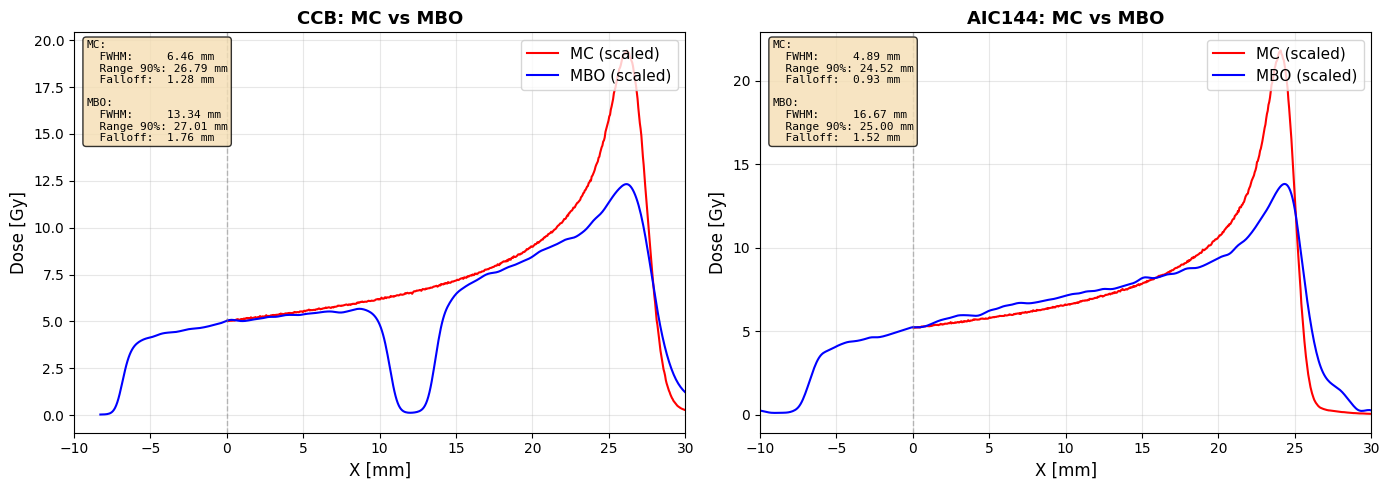

In [26]:
# MC vs MBO for both facilities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scale MC to match EBT at X=0 for each facility (for fair comparison)
mc_interp_ccb, mc_dose_at_0_ccb = normalize_to_x0(df_mc_ccb['depth'], df_mc_ccb['dose'])
scale_mc_ccb = ebt_dose_at_0_ccb / mc_dose_at_0_ccb
df_mc_ccb['dose_scaled'] = df_mc_ccb['dose'] * scale_mc_ccb

mc_interp_aic144, mc_dose_at_0_aic144 = normalize_to_x0(df_mc_aic144['depth'], df_mc_aic144['dose'])
scale_mc_aic144 = ebt_dose_at_0_aic144 / mc_dose_at_0_aic144
df_mc_aic144['dose_scaled'] = df_mc_aic144['dose'] * scale_mc_aic144

# Left plot: CCB
ax1 = axes[0]
ax1.plot(df_mc_ccb['depth'], df_mc_ccb['dose_scaled'], 'r-', linewidth=1.5, label='MC (scaled)')
ax1.plot(mbo_ccb_x_shifted, mbo_ccb_values_scaled, 'b-', linewidth=1.5, label='MBO (scaled)')
ax1.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('X [mm]', fontsize=12)
ax1.set_ylabel('Dose [Gy]', fontsize=12)
ax1.set_title('CCB: MC vs MBO', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-10, 30)

# Metrics for CCB
fwhm_mc_ccb, x90_mc_ccb, falloff_mc_ccb = calculate_all_metrics(df_mc_ccb['depth'].values, df_mc_ccb['dose_scaled'].values)

metrics_text_ccb = (
    f"MC:\n"
    f"  FWHM:     {fwhm_mc_ccb:.2f} mm\n"
    f"  Range 90%: {x90_mc_ccb:.2f} mm\n"
    f"  Falloff:  {falloff_mc_ccb:.2f} mm\n"
    f"\n"
    f"MBO:\n"
    f"  FWHM:     {fwhm_mbo_ccb:.2f} mm\n"
    f"  Range 90%: {x90_mbo_ccb:.2f} mm\n"
    f"  Falloff:  {falloff_mbo_ccb:.2f} mm"
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.02, 0.98, metrics_text_ccb, transform=ax1.transAxes, fontsize=8,
        verticalalignment='top', horizontalalignment='left', bbox=props, family='monospace')

# Right plot: AIC144
ax2 = axes[1]
ax2.plot(df_mc_aic144['depth'], df_mc_aic144['dose_scaled'], 'r-', linewidth=1.5, label='MC (scaled)')
ax2.plot(mbo_aic144_x_shifted, mbo_aic144_values_scaled, 'b-', linewidth=1.5, label='MBO (scaled)')
ax2.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('X [mm]', fontsize=12)
ax2.set_ylabel('Dose [Gy]', fontsize=12)
ax2.set_title('AIC144: MC vs MBO', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-10, 30)

# Metrics for AIC144
fwhm_mc_aic, x90_mc_aic, falloff_mc_aic = calculate_all_metrics(df_mc_aic144['depth'].values, df_mc_aic144['dose_scaled'].values)

metrics_text_aic = (
    f"MC:\n"
    f"  FWHM:     {fwhm_mc_aic:.2f} mm\n"
    f"  Range 90%: {x90_mc_aic:.2f} mm\n"
    f"  Falloff:  {falloff_mc_aic:.2f} mm\n"
    f"\n"
    f"MBO:\n"
    f"  FWHM:     {fwhm_mbo_aic:.2f} mm\n"
    f"  Range 90%: {x90_mbo_aic:.2f} mm\n"
    f"  Falloff:  {falloff_mbo_aic:.2f} mm"
)
ax2.text(0.02, 0.98, metrics_text_aic, transform=ax2.transAxes, fontsize=8,
        verticalalignment='top', horizontalalignment='left', bbox=props, family='monospace')

plt.tight_layout()
plt.show()

## 3. Summary Metrics

Calculating key metrics (FWHM, Range 90%, Distal Falloff 80-20%) for all datasets.

In [27]:
# Calculate metrics for all datasets
metrics = []

# EBT CCB
fwhm, x90, falloff = calculate_all_metrics(df_ebt_ccb['x_mm'].values, df_ebt_ccb['dose_Gy'].values)
metrics.append({'Facility': 'CCB', 'Data Type': 'EBT3', 'FWHM [mm]': fwhm, 'Range 90% [mm]': x90, 'Falloff 80-20 [mm]': falloff})

# EBT AIC144
fwhm, x90, falloff = calculate_all_metrics(df_ebt_aic144['x_mm'].values, df_ebt_aic144['dose_Gy'].values)
metrics.append({'Facility': 'AIC144', 'Data Type': 'EBT3', 'FWHM [mm]': fwhm, 'Range 90% [mm]': x90, 'Falloff 80-20 [mm]': falloff})

# MC CCB
fwhm, x90, falloff = calculate_all_metrics(df_mc_ccb['depth'].values, df_mc_ccb['dose'].values)
metrics.append({'Facility': 'CCB', 'Data Type': 'MC', 'FWHM [mm]': fwhm, 'Range 90% [mm]': x90, 'Falloff 80-20 [mm]': falloff})

# MC AIC144
fwhm, x90, falloff = calculate_all_metrics(df_mc_aic144['depth'].values, df_mc_aic144['dose'].values)
metrics.append({'Facility': 'AIC144', 'Data Type': 'MC', 'FWHM [mm]': fwhm, 'Range 90% [mm]': x90, 'Falloff 80-20 [mm]': falloff})

# MBO CCB
fwhm, x90, falloff = calculate_all_metrics(mbo_ccb_x_shifted, mbo_ccb_values_scaled)
metrics.append({'Facility': 'CCB', 'Data Type': 'MBO', 'FWHM [mm]': fwhm, 'Range 90% [mm]': x90, 'Falloff 80-20 [mm]': falloff})

# MBO AIC144
fwhm, x90, falloff = calculate_all_metrics(mbo_aic144_x_shifted, mbo_aic144_values_scaled)
metrics.append({'Facility': 'AIC144', 'Data Type': 'MBO', 'FWHM [mm]': fwhm, 'Range 90% [mm]': x90, 'Falloff 80-20 [mm]': falloff})

df_metrics = pd.DataFrame(metrics)
print("Summary Metrics Table:")
print(df_metrics.to_string(index=False, float_format='%.2f'))

Summary Metrics Table:
Facility Data Type  FWHM [mm]  Range 90% [mm]  Falloff 80-20 [mm]
     CCB      EBT3       9.32           26.74                1.25
  AIC144      EBT3       6.57           24.91                0.92
     CCB        MC       6.46           26.79                1.28
  AIC144        MC       4.89           24.52                0.93
     CCB       MBO      13.34           27.01                1.76
  AIC144       MBO      16.67           25.00                1.52


In [28]:
# Comparison analysis
print("=" * 60)
print("COMPARISON ANALYSIS")
print("=" * 60)

# Pivot table for easier comparison
df_pivot = df_metrics.pivot(index='Facility', columns='Data Type', values=['FWHM [mm]', 'Range 90% [mm]', 'Falloff 80-20 [mm]'])
print("\n--- FWHM Comparison ---")
print(df_pivot['FWHM [mm]'].to_string(float_format='%.2f'))

print("\n--- Range 90% (Distal) Comparison ---")
print(df_pivot['Range 90% [mm]'].to_string(float_format='%.2f'))

print("\n--- Distal Falloff 80-20% Comparison ---")
print(df_pivot['Falloff 80-20 [mm]'].to_string(float_format='%.2f'))

# Calculate differences
print("\n--- MC vs EBT3 Differences ---")
for facility in ['CCB', 'AIC144']:
    mc_row = df_metrics[(df_metrics['Facility'] == facility) & (df_metrics['Data Type'] == 'MC')]
    ebt_row = df_metrics[(df_metrics['Facility'] == facility) & (df_metrics['Data Type'] == 'EBT3')]
    
    mc_fwhm = mc_row['FWHM [mm]'].values[0]
    ebt_fwhm = ebt_row['FWHM [mm]'].values[0]
    mc_x90 = mc_row['Range 90% [mm]'].values[0]
    ebt_x90 = ebt_row['Range 90% [mm]'].values[0]
    mc_fall = mc_row['Falloff 80-20 [mm]'].values[0]
    ebt_fall = ebt_row['Falloff 80-20 [mm]'].values[0]
    
    print(f"\n{facility}:")
    if mc_fwhm and ebt_fwhm:
        print(f"  FWHM diff (MC-EBT3):    {mc_fwhm - ebt_fwhm:.2f} mm ({(mc_fwhm/ebt_fwhm - 1)*100:.1f}%)")
    if mc_x90 and ebt_x90:
        print(f"  Range 90% diff (MC-EBT3): {mc_x90 - ebt_x90:.2f} mm ({(mc_x90/ebt_x90 - 1)*100:.1f}%)")
    if mc_fall and ebt_fall:
        print(f"  Falloff diff (MC-EBT3): {mc_fall - ebt_fall:.2f} mm ({(mc_fall/ebt_fall - 1)*100:.1f}%)")

print("\n--- MBO vs EBT3 Differences ---")
for facility in ['CCB', 'AIC144']:
    mbo_row = df_metrics[(df_metrics['Facility'] == facility) & (df_metrics['Data Type'] == 'MBO')]
    ebt_row = df_metrics[(df_metrics['Facility'] == facility) & (df_metrics['Data Type'] == 'EBT3')]
    
    mbo_fwhm = mbo_row['FWHM [mm]'].values[0]
    ebt_fwhm = ebt_row['FWHM [mm]'].values[0]
    mbo_x90 = mbo_row['Range 90% [mm]'].values[0]
    ebt_x90 = ebt_row['Range 90% [mm]'].values[0]
    mbo_fall = mbo_row['Falloff 80-20 [mm]'].values[0]
    ebt_fall = ebt_row['Falloff 80-20 [mm]'].values[0]
    
    print(f"\n{facility}:")
    if mbo_fwhm and ebt_fwhm:
        print(f"  FWHM diff (MBO-EBT3):    {mbo_fwhm - ebt_fwhm:.2f} mm ({(mbo_fwhm/ebt_fwhm - 1)*100:.1f}%)")
    if mbo_x90 and ebt_x90:
        print(f"  Range 90% diff (MBO-EBT3): {mbo_x90 - ebt_x90:.2f} mm ({(mbo_x90/ebt_x90 - 1)*100:.1f}%)")
    if mbo_fall and ebt_fall:
        print(f"  Falloff diff (MBO-EBT3): {mbo_fall - ebt_fall:.2f} mm ({(mbo_fall/ebt_fall - 1)*100:.1f}%)")

print("\n--- MBO vs MC Differences ---")
for facility in ['CCB', 'AIC144']:
    mbo_row = df_metrics[(df_metrics['Facility'] == facility) & (df_metrics['Data Type'] == 'MBO')]
    mc_row = df_metrics[(df_metrics['Facility'] == facility) & (df_metrics['Data Type'] == 'MC')]
    
    mbo_fwhm = mbo_row['FWHM [mm]'].values[0]
    mc_fwhm = mc_row['FWHM [mm]'].values[0]
    mbo_x90 = mbo_row['Range 90% [mm]'].values[0]
    mc_x90 = mc_row['Range 90% [mm]'].values[0]
    mbo_fall = mbo_row['Falloff 80-20 [mm]'].values[0]
    mc_fall = mc_row['Falloff 80-20 [mm]'].values[0]
    
    print(f"\n{facility}:")
    if mbo_fwhm and mc_fwhm:
        print(f"  FWHM diff (MBO-MC):    {mbo_fwhm - mc_fwhm:.2f} mm ({(mbo_fwhm/mc_fwhm - 1)*100:.1f}%)")
    if mbo_x90 and mc_x90:
        print(f"  Range 90% diff (MBO-MC): {mbo_x90 - mc_x90:.2f} mm ({(mbo_x90/mc_x90 - 1)*100:.1f}%)")
    if mbo_fall and mc_fall:
        print(f"  Falloff diff (MBO-MC): {mbo_fall - mc_fall:.2f} mm ({(mbo_fall/mc_fall - 1)*100:.1f}%)")

# CCB vs AIC144 comparison
print("\n--- Facility Differences (EBT3) ---")
ccb_ebt = df_metrics[(df_metrics['Facility'] == 'CCB') & (df_metrics['Data Type'] == 'EBT3')]
aic_ebt = df_metrics[(df_metrics['Facility'] == 'AIC144') & (df_metrics['Data Type'] == 'EBT3')]
print(f"FWHM (CCB - AIC144):     {ccb_ebt['FWHM [mm]'].values[0] - aic_ebt['FWHM [mm]'].values[0]:.2f} mm")
print(f"Range 90% (CCB - AIC144): {ccb_ebt['Range 90% [mm]'].values[0] - aic_ebt['Range 90% [mm]'].values[0]:.2f} mm")
print(f"Falloff (CCB - AIC144):  {ccb_ebt['Falloff 80-20 [mm]'].values[0] - aic_ebt['Falloff 80-20 [mm]'].values[0]:.2f} mm")

print("\n--- Facility Differences (MBO) ---")
ccb_mbo = df_metrics[(df_metrics['Facility'] == 'CCB') & (df_metrics['Data Type'] == 'MBO')]
aic_mbo = df_metrics[(df_metrics['Facility'] == 'AIC144') & (df_metrics['Data Type'] == 'MBO')]
print(f"FWHM (CCB - AIC144):     {ccb_mbo['FWHM [mm]'].values[0] - aic_mbo['FWHM [mm]'].values[0]:.2f} mm")
print(f"Range 90% (CCB - AIC144): {ccb_mbo['Range 90% [mm]'].values[0] - aic_mbo['Range 90% [mm]'].values[0]:.2f} mm")
print(f"Falloff (CCB - AIC144):  {ccb_mbo['Falloff 80-20 [mm]'].values[0] - aic_mbo['Falloff 80-20 [mm]'].values[0]:.2f} mm")

COMPARISON ANALYSIS

--- FWHM Comparison ---
Data Type  EBT3   MBO   MC
Facility                  
AIC144     6.57 16.67 4.89
CCB        9.32 13.34 6.46

--- Range 90% (Distal) Comparison ---
Data Type  EBT3   MBO    MC
Facility                   
AIC144    24.91 25.00 24.52
CCB       26.74 27.01 26.79

--- Distal Falloff 80-20% Comparison ---
Data Type  EBT3  MBO   MC
Facility                 
AIC144     0.92 1.52 0.93
CCB        1.25 1.76 1.28

--- MC vs EBT3 Differences ---

CCB:
  FWHM diff (MC-EBT3):    -2.86 mm (-30.7%)
  Range 90% diff (MC-EBT3): 0.06 mm (0.2%)
  Falloff diff (MC-EBT3): 0.03 mm (2.5%)

AIC144:
  FWHM diff (MC-EBT3):    -1.68 mm (-25.6%)
  Range 90% diff (MC-EBT3): -0.39 mm (-1.6%)
  Falloff diff (MC-EBT3): 0.00 mm (0.3%)

--- MBO vs EBT3 Differences ---

CCB:
  FWHM diff (MBO-EBT3):    4.02 mm (43.1%)
  Range 90% diff (MBO-EBT3): 0.28 mm (1.0%)
  Falloff diff (MBO-EBT3): 0.52 mm (41.4%)

AIC144:
  FWHM diff (MBO-EBT3):    10.10 mm (153.6%)
  Range 90% diff (MBO-

## 4. Combined Visualization

All dose profiles with MC rescaled to match corresponding EBT3 dose at X = 0 mm.

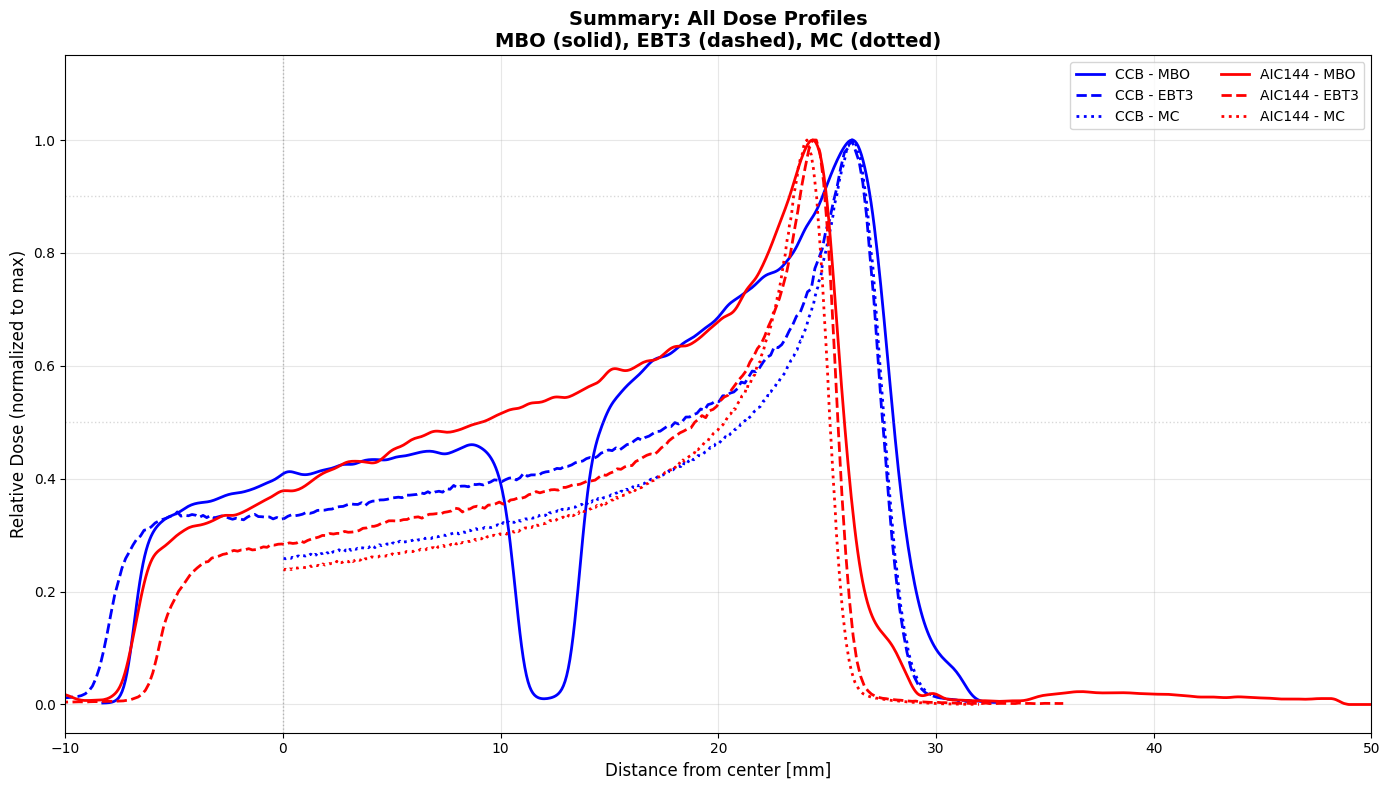

Combined plot saved as 'combined_all_profiles.png'

Line styles: MBO (solid), EBT3 (dashed), MC (dotted)
Colors: CCB (blue), AIC144 (red)


In [29]:
# Combined plot: MBO (solid), EBT3 (dashed), MC (dotted)
# Normalize all data to max = 1 for comparison
fig, ax = plt.subplots(figsize=(14, 8))

# Normalize EBT data to max
ebt_ccb_norm = df_ebt_ccb['dose_Gy'] / df_ebt_ccb['dose_Gy'].max()
ebt_aic_norm = df_ebt_aic144['dose_Gy'] / df_ebt_aic144['dose_Gy'].max()

# Normalize MC data to max
mc_ccb_norm = df_mc_ccb['dose'] / df_mc_ccb['dose'].max()
mc_aic_norm = df_mc_aic144['dose'] / df_mc_aic144['dose'].max()

# Normalize MBO data to max
mbo_ccb_norm = mbo_ccb_values_scaled / mbo_ccb_values_scaled.max()
mbo_aic_norm = mbo_aic144_values_scaled / mbo_aic144_values_scaled.max()

# CCB data (blue)
ax.plot(mbo_ccb_x_shifted, mbo_ccb_norm, 
        'b-', linewidth=2, label='CCB - MBO')
ax.plot(df_ebt_ccb['x_mm'], ebt_ccb_norm, 
        'b--', linewidth=2, label='CCB - EBT3')
ax.plot(df_mc_ccb['depth'], mc_ccb_norm, 
        'b:', linewidth=2, label='CCB - MC')

# AIC144 data (red)
ax.plot(mbo_aic144_x_shifted, mbo_aic_norm, 
        'r-', linewidth=2, label='AIC144 - MBO')
ax.plot(df_ebt_aic144['x_mm'], ebt_aic_norm, 
        'r--', linewidth=2, label='AIC144 - EBT3')
ax.plot(df_mc_aic144['depth'], mc_aic_norm, 
        'r:', linewidth=2, label='AIC144 - MC')

# Reference lines
ax.axvline(x=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.3)
ax.axhline(y=0.9, color='gray', linestyle=':', linewidth=1, alpha=0.3)

ax.set_xlabel('Distance from center [mm]', fontsize=12)
ax.set_ylabel('Relative Dose (normalized to max)', fontsize=12)
ax.set_title('Summary: All Dose Profiles\nMBO (solid), EBT3 (dashed), MC (dotted)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xlim(-10, 50)
ax.set_ylim(-0.05, 1.15)

plt.tight_layout()
plt.savefig('combined_all_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

print("Combined plot saved as 'combined_all_profiles.png'")
print("\nLine styles: MBO (solid), EBT3 (dashed), MC (dotted)")
print("Colors: CCB (blue), AIC144 (red)")

## Summary

This notebook compared dose profiles from two perspectives:

### CCB vs AIC144
- Compared profiles from two different facilities/configurations
- Both EBT3 measurements and MC simulations show similar trends

### MC vs EBT3
- Monte Carlo simulations were scaled to match EBT3 at the reference position (X=0)
- Good agreement between simulation and measurement validates the MC model

### Metrics reported on each plot:
- **FWHM**: Full Width at Half Maximum
- **Range 90%**: Position where dose drops to 90% on the distal falloff
- **Falloff 80-20%**: Distal falloff distance from 80% to 20% dose level